# Forecasting (Entrega en semana 13)
Create a model using linear regression and predict new data. Use a time series.

Para la siguiente practica usaremos como variable en x los años y la variable y sera el promedio de ventas globales en ese año.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

data = pd.read_csv("../datasets/vgsales_clean.csv")
total_anios = data.groupby(["Año"])["Ventas_Globales"].sum()
total_anios

Año
1980     10.89
1981     31.18
1982     26.15
1983     15.66
1984     49.14
1985     53.53
1986     37.07
1987     21.27
1988     39.42
1989     67.73
1990     43.14
1991     31.50
1992     72.15
1993     45.76
1994     73.31
1995     82.66
1996    193.50
1997    192.94
1998    241.36
1999    230.21
2000    178.70
2001    296.01
2002    325.66
2003    274.08
2004    329.16
2005    376.56
2006    441.48
2007    453.05
2008    472.34
2009    483.44
2010    431.13
2011    342.38
2012    240.97
2013    217.10
2014    163.26
2015    168.92
2016     49.73
2017      0.04
2020      0.29
Name: Ventas_Globales, dtype: float64

EL siguiente es un plot que muestra la relacion que existe entre la variable años con las ventas globales.

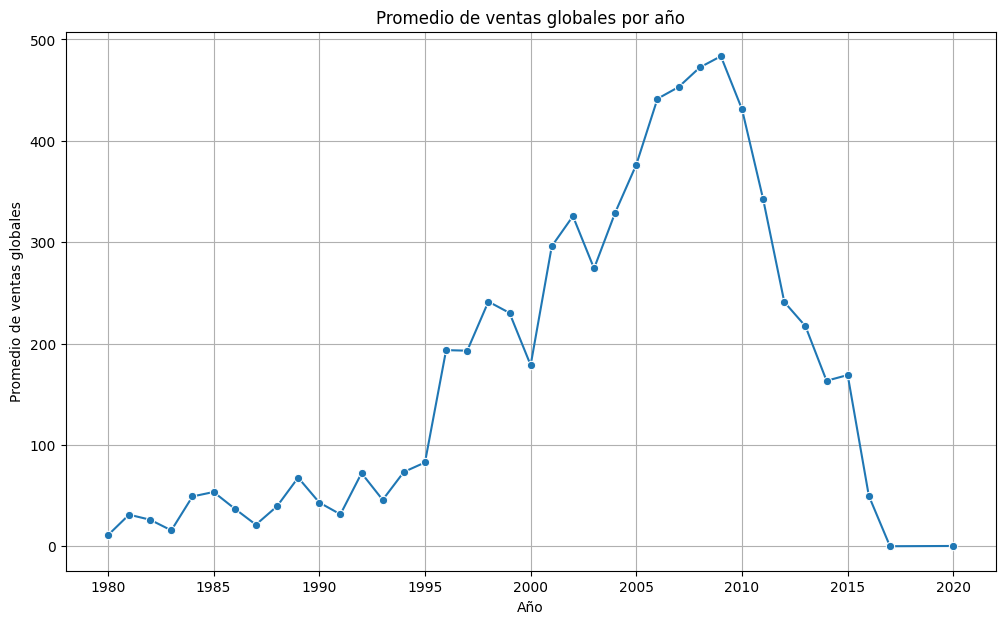

In [71]:
# Mostramos distribucion de los datos por anios
plt.figure(figsize=(12, 7))
sns.lineplot(x=total_anios.index, y=total_anios.values, marker='o')
plt.title('Promedio de ventas globales por año')
plt.xlabel('Año')
plt.ylabel('Promedio de ventas globales')
plt.grid(True)
plt.show()

Ahora procedemos a realizar el modelo, para lo siguiente pedimos prestado una funcion que realizamos en la practia 5 donde tratabamos igualmente una regresion lineal pero con los datos de ventas globales y norteamericanas. 

R² Score: 0.2696   ---   El modelo no predice con exito la variable dependiente



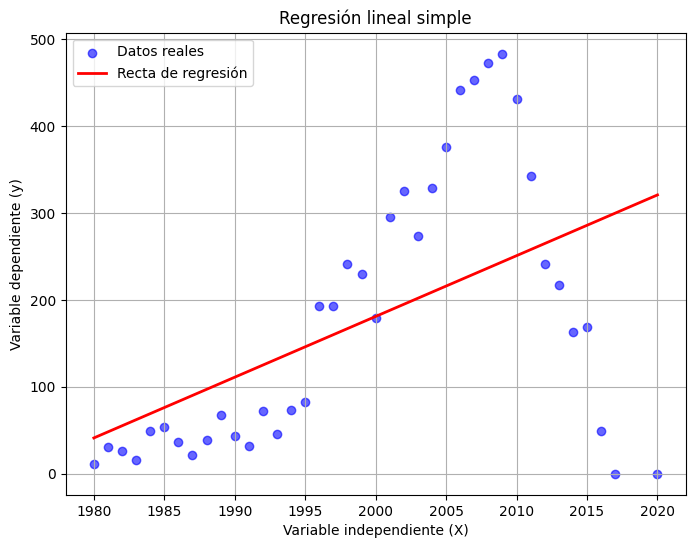

In [72]:
def modelo_lineal_simple(X, y):
    """Imprime un grafico de la regresion lineal junto a los datos originales, aparte de 
    retornar el modelo de regresion"""
    X = np.array(X).reshape(-1, 1)
    y = np.array(y)

    # Crear y entrenar el modelo
    modelo = LinearRegression()
    modelo.fit(X, y)

    # Predicciones
    y_pred = modelo.predict(X)

    # Calcular R²
    r2 = r2_score(y, y_pred)

    if r2 > 0.80:
        print(f"R² Score: {r2:.4f}   ---   El modelo predice con exito la variable dependiente", end="\n\n")
    else:
        print(f"R² Score: {r2:.4f}   ---   El modelo no predice con exito la variable dependiente", end="\n\n")
    

    # Graficar la recta de regresión junto con los datos originales
    plt.figure(figsize=(8, 6))
    plt.scatter(X, y, color='blue', label='Datos reales', alpha=0.6)
    plt.plot(X, y_pred, color='red', linewidth=2, label='Recta de regresión')
    plt.xlabel('Variable independiente (X)')
    plt.ylabel('Variable dependiente (y)')
    plt.title('Regresión lineal simple')
    plt.legend()
    plt.grid(True)
    plt.show()

    return modelo


X = total_anios.index  # variable independiente
y = total_anios.values      # variable dependiente
#uso del modelo
modelo = modelo_lineal_simple(X, y)

Como podemos apreciar arriba, el modelo nos retorna que no puede predecir la variable independiente con exito, esto se debe al break que existe depues del anio del 2010. Este break se debe a que hay un problema de origen de los datos, que es que no se registraron el mismo volumen de juegos depues de este anio, lo que repercute en una baja de ventas en el contexto global. 

Para arreglar esto restringiremos los datos para que solo se expongan al modelo los videojuegos del 1980 al 2010.

R² Score: 0.8762   ---   El modelo predice con exito la variable dependiente



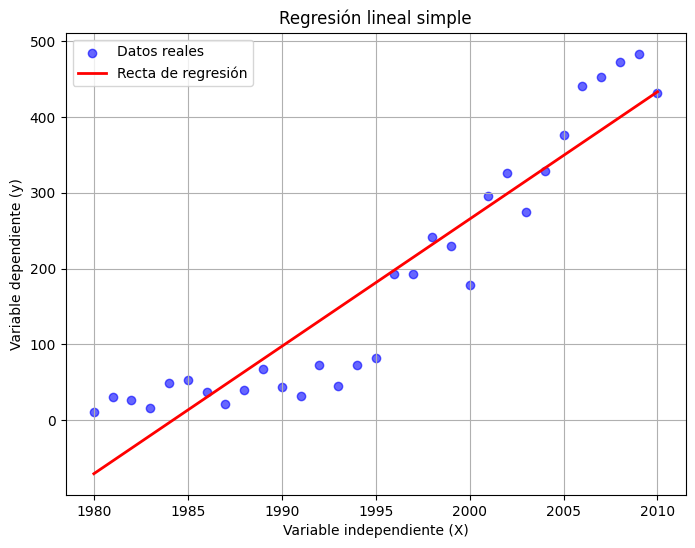

In [78]:
anios_acortados =  total_anios.loc[1980:2010]
anios_acortados
X = anios_acortados.index  # variable independiente
y = anios_acortados.values      # variable dependiente
#uso del modelo
modelo = modelo_lineal_simple(X, y)

Ahora el modelo nos retorna que puede predecir con exito la variable independiente. Por lo que podemos empezar a predecir algunos anios despues del 2010 que estaran mas apegados a lo que el modelo en un principio pudiera retornarnos si no existiara el break antes mencionado. 

# prediccion de datos

Ahora que tenemos el modelo, podemos usarlo para predecir algunos datos puntuales, en el siguiente codigo se intenta predecir el anio 2012 que no se encuentra originalmente en el entrenamiento del modelo.

In [79]:
#inicializamos valores
anio = 2012
valor_a_predecir = np.array([[anio]])

# Se usa el método .predict() del modelo
prediccion = modelo.predict(valor_a_predecir)

print(f"Para el anio {anio}, se predicen {prediccion[0]:.2f} millones en ventas globales.")

Para el anio 2012, se predicen 466.80 millones en ventas globales.


Tambien podemos usar el modelo para predecir multiples datos, si es que usamos un array en lugar de un dato puntual. 

In [81]:
# Lista de anios
anios = [2011, 2012, 2013, 2014]
valores_a_predecir = np.array(anios).reshape(-1, 1)

# Realizar las predicciones
predicciones_multiples = modelo.predict(valores_a_predecir)

print("--- Predicciones Múltiples ---")
for valor, pred in zip(anios, predicciones_multiples):
    print(f"Anio: {valor} -> Total de Ventas Globales: {pred:.2f}")

--- Predicciones Múltiples ---
Anio: 2011 -> Total de Ventas Globales: 450.01
Anio: 2012 -> Total de Ventas Globales: 466.80
Anio: 2013 -> Total de Ventas Globales: 483.59
Anio: 2014 -> Total de Ventas Globales: 500.39
